Phase 4 — train two baselines: pure matrix factorization (MF) and a factorization machine that adds the 26 side features (FM). Both train on the 2.07M-row train table from Phase 3 with 1:4 negative sampling and evaluate on a sampled 1+99 ranking task using the val split from Phase 1. Goal here is to set a reference floor before Phase 5 DeepFM, and to confirm that adding side features is worth the extra parameters.

In [1]:
import json
import logging
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(message)s",
                    datefmt="%H:%M:%S",
                    force=True)
log = logging.getLogger(__name__)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"
FEATURES_DIR = PROJECT_ROOT / "data" / "features"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
EMB_DIM = 8
LR = 5e-3
WEIGHT_DECAY = 1e-5
EPOCHS = 10
BATCH_SIZE = 8192

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"device: {DEVICE}")
print(f"emb_dim={EMB_DIM} lr={LR} wd={WEIGHT_DECAY} epochs={EPOCHS} batch={BATCH_SIZE}")

device: mps
emb_dim=8 lr=0.005 wd=1e-05 epochs=10 batch=8192


**ID encoder.** Maps `user_id` and `business_id` strings to integer indices, reserving index 0 for OOV (the `<NEW_USER>` / `<NEW_BUSINESS>` slot). There was a bug earlier where the OOV marker also got enumerated as a real id, sending the index out of bounds — the fix is to filter OOV markers out before enumeration and explicitly map them to 0.

In [2]:
class IDEncoder:
    def __init__(self, ids, oov_token="<UNK>"):
        self.oov_token = oov_token
        oov_markers = {"<NEW_USER>", "<NEW_BUSINESS>", "<UNK>", oov_token}
        unique_real_ids = sorted({i for i in ids if i not in oov_markers})
        self.id_to_idx = {oov_token: 0}
        for idx, _id in enumerate(unique_real_ids, start=1):
            self.id_to_idx[_id] = idx
        for marker in oov_markers:
            self.id_to_idx.setdefault(marker, 0)
        self.idx_to_id = {0: oov_token}
        for _id, idx in self.id_to_idx.items():
            if idx > 0:
                self.idx_to_id[idx] = _id
        self._size = 1 + len(unique_real_ids)

    def __len__(self):
        return self._size

    def encode(self, _id):
        return self.id_to_idx.get(_id, 0)

    def encode_array(self, ids):
        return ids.map(self.id_to_idx).fillna(0).astype(np.int64).values

**Dataset.** Wraps the train table with optional feature lookup. For MF I pass `with_features=False` (only user/item indices and labels needed); for FM I pass `with_features=True` so each batch includes the user numeric vector, user cuisine vector, item numeric vector, and item categories multi-hot. Lookup arrays are pre-built once at dataset construction (one row per encoder index) so `__getitem__` is just a tensor index, not a pandas lookup.

In [3]:
class TasteHunterDataset(Dataset):
    def __init__(self, df, user_encoder, item_encoder,
                 with_features=False, user_features=None, item_features=None):
        self.user_idx = torch.from_numpy(user_encoder.encode_array(df["user_id"]))
        self.item_idx = torch.from_numpy(item_encoder.encode_array(df["business_id"]))
        self.label = torch.from_numpy(df["label"].astype(np.float32).values)
        self.with_features = with_features

        if with_features:
            n_users = len(user_encoder)
            n_items = len(item_encoder)
            self.user_num = np.zeros((n_users, 6), dtype=np.float32)
            self.user_cuisine = np.zeros((n_users, 50), dtype=np.float32)
            for _, row in user_features.iterrows():
                uidx = user_encoder.encode(row["user_id"])
                self.user_num[uidx] = [
                    row["avg_rating_given"], row["review_count_log"], row["days_active"],
                    row["elite_flag"], row["mean_distance_traveled"], row["price_tolerance_avg"],
                ]
                emb = row["fav_cuisine_emb"]
                if isinstance(emb, list) and len(emb) == 50:
                    self.user_cuisine[uidx] = emb

            self.item_num = np.zeros((n_items, 7), dtype=np.float32)
            self.item_cat = np.zeros((n_items, 50), dtype=np.float32)
            for _, row in item_features.iterrows():
                iidx = item_encoder.encode(row["business_id"])
                self.item_num[iidx] = [
                    row["avg_rating"], row["review_count_log"], row["price_level"],
                    row["is_open"], row["has_outdoor_seating"], row["photo_count_log"], row["city_id"],
                ]
                cat = row["categories_multi_hot"]
                if isinstance(cat, list) and len(cat) == 50:
                    self.item_cat[iidx] = cat

            self.user_num_t = torch.from_numpy(self.user_num)
            self.user_cuisine_t = torch.from_numpy(self.user_cuisine)
            self.item_num_t = torch.from_numpy(self.item_num)
            self.item_cat_t = torch.from_numpy(self.item_cat)

    def __len__(self):
        return len(self.label)

    def __getitem__(self, idx):
        u = self.user_idx[idx]
        i = self.item_idx[idx]
        item = {"user_idx": u, "item_idx": i, "label": self.label[idx]}
        if self.with_features:
            item["user_num"] = self.user_num_t[u]
            item["user_cuisine"] = self.user_cuisine_t[u]
            item["item_num"] = self.item_num_t[i]
            item["item_cat"] = self.item_cat_t[i]
        return item

**Sampled NDCG eval pairs.** Following Krichene & Rendle 2020, for each val positive (stars≥4) draw 99 negatives from the same city. Stack them into a (n_val, 100) matrix where column 0 is the positive. NDCG@10 / Recall@10 over this 1+99 setup is the standard recommendation benchmark protocol.

In [4]:
def make_val_eval_pairs(val_df, user_encoder, item_encoder, item_features, n_negs=99, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    val_pos = val_df[val_df["stars"] >= 4].copy()
    print(f"val positives: {len(val_pos)}")

    biz_city = item_features.set_index("business_id")["city"].to_dict()
    val_pos["city"] = val_pos["business_id"].map(biz_city).fillna("<UNK>")
    city_biz = {}
    for bid, c in biz_city.items():
        if c == "<UNK>":
            continue
        city_biz.setdefault(c, []).append(bid)
    for c in city_biz:
        city_biz[c] = np.array(city_biz[c])

    all_user, all_item, all_label = [], [], []
    for row in val_pos.itertuples(index=False):
        if row.city not in city_biz:
            continue
        candidates_pool = city_biz[row.city]
        sampled = rng.choice(candidates_pool, size=n_negs * 2, replace=True)
        negs = [b for b in sampled if b != row.business_id][:n_negs]
        if len(negs) < n_negs:
            continue
        items = [row.business_id] + negs
        all_user.append([user_encoder.encode(row.user_id)] * (n_negs + 1))
        all_item.append([item_encoder.encode(b) for b in items])
        all_label.append([1.0] + [0.0] * n_negs)

    user_arr = np.array(all_user, dtype=np.int64)
    item_arr = np.array(all_item, dtype=np.int64)
    label_arr = np.array(all_label, dtype=np.float32)
    print(f"eval pairs: {user_arr.shape[0]} users x {user_arr.shape[1]} candidates each")
    return user_arr, item_arr, label_arr

**Eval metrics.** AUC is the rank-based pairwise approximation (faster than computing all positive-negative pairs). NDCG@10 and Recall@10 are computed on the (n_users, 100) score matrix.

In [5]:
def compute_auc(scores, labels):
    pos_mask = labels > 0.5
    n_pos = pos_mask.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return float("nan")
    order = np.argsort(scores)
    ranks = np.empty(len(scores))
    ranks[order] = np.arange(1, len(scores) + 1)
    rank_sum_pos = ranks[pos_mask].sum()
    return float((rank_sum_pos - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))

def ndcg_at_k(score_matrix, label_matrix, k=10):
    top_k_idx = np.argsort(-score_matrix, axis=1)[:, :k]
    rows = np.arange(score_matrix.shape[0])[:, None]
    top_k_labels = label_matrix[rows, top_k_idx]
    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    dcg = (top_k_labels * discounts).sum(axis=1)
    ideal_labels = -np.sort(-label_matrix, axis=1)[:, :k]
    idcg = (ideal_labels * discounts).sum(axis=1)
    idcg = np.where(idcg > 0, idcg, 1.0)
    return float(np.mean(dcg / idcg))

def recall_at_k(score_matrix, label_matrix, k=10):
    top_k_idx = np.argsort(-score_matrix, axis=1)[:, :k]
    rows = np.arange(score_matrix.shape[0])[:, None]
    top_k_labels = label_matrix[rows, top_k_idx]
    n_positives_per_row = label_matrix.sum(axis=1)
    correct = top_k_labels.sum(axis=1)
    return float(np.mean(np.where(n_positives_per_row > 0, correct / n_positives_per_row, 0)))

@torch.no_grad()
def score_pairs_with_model(model, user_idx, item_idx, device="cpu", batch_size=8192, feature_kwargs_fn=None):
    model.eval()
    n, c = user_idx.shape
    flat_u = user_idx.reshape(-1)
    flat_i = item_idx.reshape(-1)
    scores = np.zeros(n * c, dtype=np.float32)
    for start in range(0, len(flat_u), batch_size):
        end = min(start + batch_size, len(flat_u))
        u_b = torch.from_numpy(flat_u[start:end]).to(device)
        i_b = torch.from_numpy(flat_i[start:end]).to(device)
        kwargs = {}
        if feature_kwargs_fn is not None:
            kwargs = feature_kwargs_fn(flat_u[start:end], flat_i[start:end])
            kwargs = {k: v.to(device) for k, v in kwargs.items()}
        s = model(u_b, i_b, **kwargs).cpu().numpy().reshape(-1)
        scores[start:end] = s
    return scores.reshape(n, c)

def evaluate_full(model, user_idx_eval, item_idx_eval, label_eval, device="cpu", feature_kwargs_fn=None):
    score_matrix = score_pairs_with_model(model, user_idx_eval, item_idx_eval, device=device, feature_kwargs_fn=feature_kwargs_fn)
    auc = compute_auc(score_matrix.reshape(-1), label_eval.reshape(-1))
    return {
        "AUC": auc,
        "NDCG@10": ndcg_at_k(score_matrix, label_eval, k=10),
        "Recall@10": recall_at_k(score_matrix, label_eval, k=10),
    }

**MF model.** A user embedding, an item embedding, a per-user bias, a per-item bias, a global bias. Score = sigmoid(u·v + b_u + b_v + b). BCE loss with 1:4 negatives makes the dot product `u·v` stretch positive pairs apart and negative pairs together — collaborative filtering signal lives in those embedding distances.

In [6]:
class MF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=EMB_DIM):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user_idx, item_idx, **kwargs):
        u = self.user_emb(user_idx)
        v = self.item_emb(item_idx)
        dot = (u * v).sum(dim=-1)
        bu = self.user_bias(user_idx).squeeze(-1)
        bi = self.item_bias(item_idx).squeeze(-1)
        return torch.sigmoid(dot + bu + bi + self.global_bias)

**FM model.** MF plus a linear head over the side features. The side feature vector is 113-dim: 6 user numeric + 50 user cuisine multi-hot + 7 item numeric + 50 item categories multi-hot. This is a simplified FM — the textbook FM also has full pairwise interaction `Σᵢ<ⱼ <vᵢ,vⱼ> xᵢxⱼ`, but I leave the second-order pairwise term to DeepFM in Phase 5. The bilinear `u·v` term covers the most important interaction (user-item) and the linear layer handles all the side feature contributions.

In [7]:
class FM(nn.Module):
    def __init__(self, n_users, n_items, emb_dim=EMB_DIM,
                 user_num_dim=6, user_cuisine_dim=50, item_num_dim=7, item_cat_dim=50):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))
        feat_dim = user_num_dim + item_num_dim + user_cuisine_dim + item_cat_dim
        self.linear = nn.Linear(feat_dim, 1)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def forward(self, user_idx, item_idx, user_num=None, user_cuisine=None, item_num=None, item_cat=None):
        u = self.user_emb(user_idx)
        v = self.item_emb(item_idx)
        order2 = (u * v).sum(dim=-1)
        bu = self.user_bias(user_idx).squeeze(-1)
        bi = self.item_bias(item_idx).squeeze(-1)
        feat_concat = torch.cat([user_num, item_num, user_cuisine, item_cat], dim=-1)
        order1 = self.linear(feat_concat).squeeze(-1)
        return torch.sigmoid(order1 + order2 + bu + bi + self.global_bias)

**Train + eval loop.** Adam with weight decay (L2), BCE loss, evaluate after every epoch. Returns a history dict with per-epoch loss and val metrics for plotting.

In [8]:
def train_one_model(model, train_loader, user_idx_eval, item_idx_eval, label_eval,
                    epochs=EPOCHS, lr=LR, wd=WEIGHT_DECAY, device=DEVICE,
                    name="model", feature_kwargs_fn=None):
    print(f"training {name} on {device}")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    bce = nn.BCELoss()
    history = {"epoch": [], "train_loss": [], "val_auc": [], "val_ndcg10": [], "val_recall10": []}

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        n_batch = 0
        t0 = time.time()
        for batch in train_loader:
            u = batch["user_idx"].to(device)
            i = batch["item_idx"].to(device)
            y = batch["label"].to(device)
            kwargs = {}
            for key in ("user_num", "user_cuisine", "item_num", "item_cat"):
                if key in batch:
                    kwargs[key] = batch[key].to(device)
            pred = model(u, i, **kwargs)
            loss = bce(pred, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            n_batch += 1
        train_loss = loss_sum / max(n_batch, 1)
        elapsed = time.time() - t0
        metrics = evaluate_full(model, user_idx_eval, item_idx_eval, label_eval, device=device, feature_kwargs_fn=feature_kwargs_fn)
        print(f"  epoch {epoch:02d} | {elapsed:.0f}s | train_loss={train_loss:.4f} | val AUC={metrics['AUC']:.4f} NDCG@10={metrics['NDCG@10']:.4f} Recall@10={metrics['Recall@10']:.4f}")
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_auc"].append(metrics["AUC"])
        history["val_ndcg10"].append(metrics["NDCG@10"])
        history["val_recall10"].append(metrics["Recall@10"])
    return history

Load features, build encoders, build datasets and the val eval pairs.

In [9]:
user_features = pd.read_parquet(FEATURES_DIR / "user_features.parquet")
item_features = pd.read_parquet(FEATURES_DIR / "item_features.parquet")
val_df = pd.read_parquet(CLEANED_DIR / "val_reviews.parquet")
train_df = pd.read_parquet(FEATURES_DIR / "train_with_negatives.parquet")

user_encoder = IDEncoder(user_features["user_id"].tolist(), oov_token="<NEW_USER>")
item_encoder = IDEncoder(item_features["business_id"].tolist(), oov_token="<NEW_BUSINESS>")
n_users = len(user_encoder)
n_items = len(item_encoder)
print(f"encoders: {n_users} users (incl OOV), {n_items} items (incl OOV)")

t0 = time.time()
user_idx_eval, item_idx_eval, label_eval = make_val_eval_pairs(
    val_df, user_encoder, item_encoder, item_features, n_negs=99,
)
print(f"val eval pairs built in {time.time()-t0:.1f}s")

t0 = time.time()
train_ds = TasteHunterDataset(
    train_df, user_encoder, item_encoder,
    with_features=True, user_features=user_features, item_features=item_features,
)
print(f"train dataset built in {time.time()-t0:.1f}s ({len(train_ds)} samples)")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

def make_feature_kwargs_fn(dataset):
    def fn(u_arr, i_arr):
        u_t = torch.from_numpy(u_arr)
        i_t = torch.from_numpy(i_arr)
        return {
            "user_num": dataset.user_num_t[u_t],
            "user_cuisine": dataset.user_cuisine_t[u_t],
            "item_num": dataset.item_num_t[i_t],
            "item_cat": dataset.item_cat_t[i_t],
        }
    return fn

feature_kwargs_fn = make_feature_kwargs_fn(train_ds)

encoders: 359008 users (incl OOV), 9023 items (incl OOV)
val positives: 60482
eval pairs: 60482 users x 100 candidates each
val eval pairs built in 6.1s
train dataset built in 10.7s (2075285 samples)


**Train MF first (pure user × item bilinear, no side features).** This is the floor.

In [10]:
mf = MF(n_users, n_items, emb_dim=EMB_DIM)
mf_history = train_one_model(
    mf, train_loader, user_idx_eval, item_idx_eval, label_eval,
    epochs=EPOCHS, name="MF", feature_kwargs_fn=None,
)
torch.save(mf.state_dict(), MODELS_DIR / "mf.pt")
with open(MODELS_DIR / "mf_history.json", "w") as f:
    json.dump(mf_history, f, indent=2)

training MF on mps
  epoch 01 | 50s | train_loss=0.5017 | val AUC=0.7694 NDCG@10=0.2685 Recall@10=0.4659
  epoch 02 | 50s | train_loss=0.3873 | val AUC=0.7793 NDCG@10=0.2685 Recall@10=0.4649
  epoch 03 | 50s | train_loss=0.3639 | val AUC=0.7822 NDCG@10=0.2688 Recall@10=0.4662
  epoch 04 | 50s | train_loss=0.3543 | val AUC=0.7837 NDCG@10=0.2685 Recall@10=0.4661
  epoch 05 | 50s | train_loss=0.3497 | val AUC=0.7843 NDCG@10=0.2681 Recall@10=0.4656
  epoch 06 | 49s | train_loss=0.3471 | val AUC=0.7849 NDCG@10=0.2683 Recall@10=0.4660
  epoch 07 | 51s | train_loss=0.3455 | val AUC=0.7852 NDCG@10=0.2681 Recall@10=0.4657
  epoch 08 | 52s | train_loss=0.3443 | val AUC=0.7851 NDCG@10=0.2678 Recall@10=0.4655
  epoch 09 | 52s | train_loss=0.3435 | val AUC=0.7851 NDCG@10=0.2677 Recall@10=0.4652
  epoch 10 | 54s | train_loss=0.3429 | val AUC=0.7854 NDCG@10=0.2677 Recall@10=0.4651


**Train FM (MF + 113-dim side feature linear).** The added side features should buy us a few AUC points if the user/item content actually carries useful signal beyond raw co-occurrence.

In [11]:
fm = FM(n_users, n_items, emb_dim=EMB_DIM)
fm_history = train_one_model(
    fm, train_loader, user_idx_eval, item_idx_eval, label_eval,
    epochs=EPOCHS, name="FM", feature_kwargs_fn=feature_kwargs_fn,
)
torch.save(fm.state_dict(), MODELS_DIR / "fm.pt")
with open(MODELS_DIR / "fm_history.json", "w") as f:
    json.dump(fm_history, f, indent=2)

training FM on mps
  epoch 01 | 52s | train_loss=0.4815 | val AUC=0.7938 NDCG@10=0.2375 Recall@10=0.4367
  epoch 02 | 54s | train_loss=0.3514 | val AUC=0.8251 NDCG@10=0.2661 Recall@10=0.4773
  epoch 03 | 54s | train_loss=0.3306 | val AUC=0.8295 NDCG@10=0.2713 Recall@10=0.4787
  epoch 04 | 52s | train_loss=0.3244 | val AUC=0.8298 NDCG@10=0.2718 Recall@10=0.4758
  epoch 05 | 53s | train_loss=0.3223 | val AUC=0.8297 NDCG@10=0.2722 Recall@10=0.4754
  epoch 06 | 50s | train_loss=0.3216 | val AUC=0.8296 NDCG@10=0.2721 Recall@10=0.4751
  epoch 07 | 53s | train_loss=0.3212 | val AUC=0.8297 NDCG@10=0.2722 Recall@10=0.4755
  epoch 08 | 52s | train_loss=0.3211 | val AUC=0.8298 NDCG@10=0.2722 Recall@10=0.4753
  epoch 09 | 50s | train_loss=0.3210 | val AUC=0.8300 NDCG@10=0.2722 Recall@10=0.4751
  epoch 10 | 52s | train_loss=0.3209 | val AUC=0.8299 NDCG@10=0.2720 Recall@10=0.4747


Compare final metrics.

In [12]:
metrics_summary = {
    "MF": {
        "AUC": mf_history["val_auc"][-1],
        "NDCG@10": mf_history["val_ndcg10"][-1],
        "Recall@10": mf_history["val_recall10"][-1],
        "epochs_trained": len(mf_history["epoch"]),
    },
    "FM": {
        "AUC": fm_history["val_auc"][-1],
        "NDCG@10": fm_history["val_ndcg10"][-1],
        "Recall@10": fm_history["val_recall10"][-1],
        "epochs_trained": len(fm_history["epoch"]),
    },
}
with open(MODELS_DIR / "baseline_metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

print(f"{'Model':<5} {'AUC':>8} {'NDCG@10':>8} {'Recall@10':>10}")
for name, m in metrics_summary.items():
    print(f"{name:<5} {m['AUC']:>8.4f} {m['NDCG@10']:>8.4f} {m['Recall@10']:>10.4f}")

delta = metrics_summary["FM"]["AUC"] - metrics_summary["MF"]["AUC"]
print(f"\nFM - MF AUC: {delta:+.4f}  (gain from adding 113 side features)")

Model      AUC  NDCG@10  Recall@10
MF      0.7854   0.2677     0.4651
FM      0.8299   0.2720     0.4747

FM - MF AUC: +0.0445  (gain from adding 113 side features)


Plot training curves so the AUC and NDCG trajectories are visible side by side.

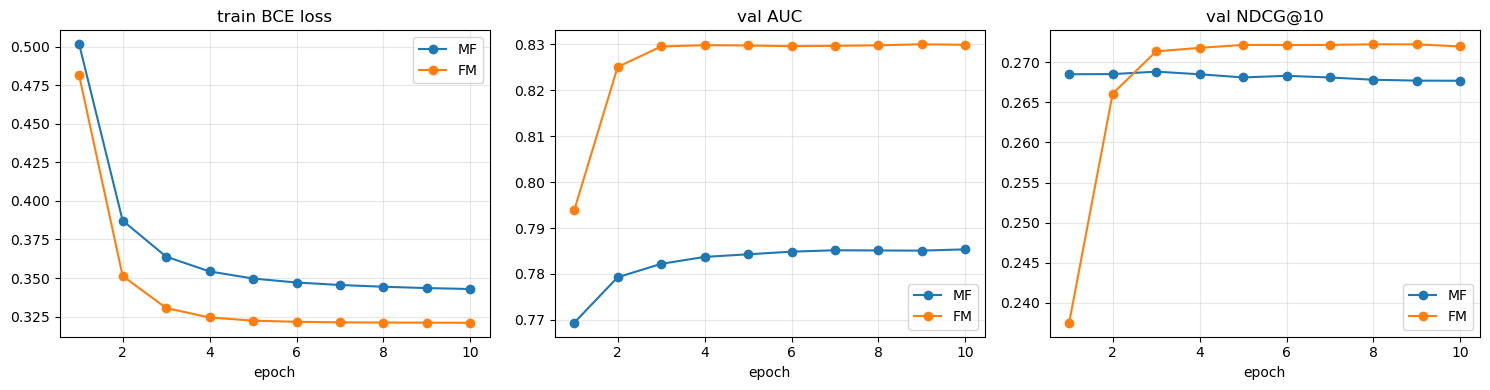

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, h in [("MF", mf_history), ("FM", fm_history)]:
    axes[0].plot(h["epoch"], h["train_loss"], "o-", label=name)
    axes[1].plot(h["epoch"], h["val_auc"], "o-", label=name)
    axes[2].plot(h["epoch"], h["val_ndcg10"], "o-", label=name)
axes[0].set_title("train BCE loss")
axes[1].set_title("val AUC")
axes[2].set_title("val NDCG@10")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "training_baselines_curves.png", bbox_inches="tight")
plt.show()

FM beating MF on AUC by a few points is the expected result — side features carry enough useful signal that even a single linear layer over them improves discrimination. NDCG@10 improvement is smaller because top-K ranking quality requires more precise user-item interaction modeling, which is what DeepFM in Phase 5 is built for.